In [1]:
import numpy as np
import scipy.constants
from scipy.integrate import quad
import pycbc.cosmology
import matplotlib.pyplot as plt
import bilby_tgr

def mg_to_lambda_g(mg):
    return scipy.constants.h / (mg * scipy.constants.c)

def lambda_g_to_mg(lambda_g):
    return scipy.constants.h / (lambda_g * scipy.constants.c)

def effective_distance(luminosity_distance):
    Omega_M = 0.315
    Omega_Lambda = 0.685
    H0 = 67.4  # km/s/Mpc
    H0_m = H0 * 1000  # convert to m/s/Mpc
    z = pycbc.cosmology.redshift(luminosity_distance)

    def integrand(zp):
        E = np.sqrt(Omega_M * (1+zp)**3 + Omega_Lambda)
        return 1.0 / ((1+zp)**2 * E)

    integral, _ = quad(integrand, 0, z)
    D = scipy.constants.c * (1 + z) / H0_m * integral # in Mpc
    return D

def effective_distance_from_z(z):
    Omega_M = 0.315
    Omega_Lambda = 0.685
    H0 = 67.4  # km/s/Mpc
    H0_m = H0 * 1000  # convert to m/s/Mpc

    def integrand(zp):
        E = np.sqrt(Omega_M * (1+zp)**3 + Omega_Lambda)
        return 1.0 / ((1+zp)**2 * E)

    integral, _ = quad(integrand, 0, z)
    D = scipy.constants.c * (1 + z) / H0_m * integral # in Mpc
    return D

/usr/lib/python3.11/importlib/__init__.py:126: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  return _bootstrap._gcd_import(name[level:], package, level)


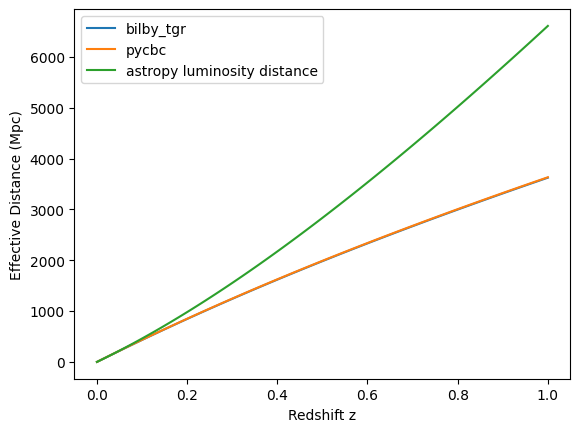

In [2]:
z = np.linspace(0,1,100)

from astropy.cosmology import FlatLambdaCDM
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)

bilby_distance = []
pycbc_distance = []
luminiosity_distance = cosmo.luminosity_distance(z).value
for zi in z:
    bilby_distance.append(bilby_tgr.mdr.conversion.redshift_to_LIV_distance_scalar(zi,0))
    pycbc_distance.append(effective_distance_from_z(zi))

plt.plot(z, bilby_distance, label='bilby_tgr')
plt.plot(z, pycbc_distance, label='pycbc')
plt.plot(z, luminiosity_distance, label='astropy luminosity distance')
plt.xlabel('Redshift z')
plt.ylabel('Effective Distance (Mpc)')
plt.legend()

In [5]:
def mg_to_lambda_g(mg):
    '''
    Convert graviton mass to Compton wavelength.

    Parameters
    ----------
    mg : float
        Graviton mass in eV/c^2

    Returns
    -------
    lambda_g : float
        Compton wavelength of graviton in km
    '''
    h_eV_s, _, _ = scipy.constants.physical_constants['Planck constant in eV/Hz']
    return h_eV_s / (mg / scipy.constants.c) / 1000 # convert from m to km

def lambda_g_to_mg(lambda_g):
    '''
    Convert graviton Compton wavelength to mass.
    
    Parameters
    ----------
    lambda_g : float
        Compton wavelength of graviton in km
    
    Returns
    -------
    mg : float
        Graviton mass in eV/c^2
    '''
    h_eV_s, _, _ = scipy.constants.physical_constants['Planck constant in eV/Hz']
    lambda_g_m = lambda_g * 1000 # convert from km to m
    return h_eV_s / (lambda_g_m / scipy.constants.c)

In [4]:
lambda_g_to_mg(1e13)

1.239841984055037e-22

In [6]:
mg_to_lambda_g(1e-22)

12398419840550.367